# 7. Neuronales Netz für Regression

**KI1-Projekt 308** — California Housing Datensatz

**Schwerpunkt P5 (Kernaufgabe):** Neuronales Netz mit TensorFlow/Keras
für die Vorhersage von Hauspreisen. Vergleich mit linearer Regression.

Vorlage: Blatt 12 (TensorFlow Regression), Kapitel 8 Folien

> ⚠️ **Python-Version:** Dieses Notebook benötigt **Python 3.13**. für intel Mac 3.11.14  
> TensorFlow (≥ 2.18) ist **nicht** kompatibel mit Python 3.14+.  
> Venv erstellen mit: `python3.13 -m venv .venv`

In [14]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LinearRegression

from utils.data import load_and_clean_data, get_train_test_split
from utils.evaluation import evaluate_predictions, add_result
from utils.plotting import plot_predicted_vs_actual, plot_residuals, save_fig

plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.16.2


## 7.1 Daten laden (skaliert)

Neuronale Netze benötigen skalierte Eingabedaten für effizientes Training.

In [15]:
df = load_and_clean_data()
X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train_nn, y_train_nn = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train_nn.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Test von NN Plain mit [64, 32] NN L2 mit [128, 64, 32] NN L1 + L2 mit [128, 64, 32] NN L2 + Dropout mit [128, 64, 32]

                        Modell  Test_MSE  Test_MAE Parameter Epochen_bis_Stop
NN_L3                    NN_L3   0.21223  0.314925     11521               56
NN_plain_klein  NN_plain_klein  0.217303   0.33045      2689               53
NN_L2                    NN_L2   0.23381  0.316675     11521              109
NN_L1_L2              NN_L1_L2   0.26939  0.338513     11521               80
NN_L1                    NN_L1  0.285747   0.34586     11521               73


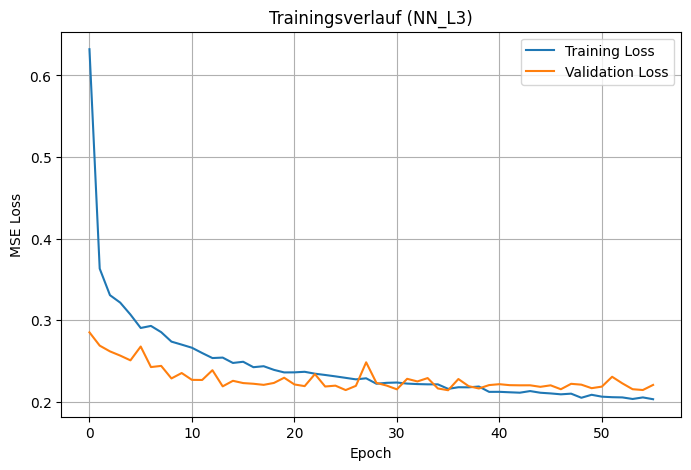

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# Optional: eigener L3 Regularizer
# --------------------------------------------------

class L3Regularizer(keras.regularizers.Regularizer):
    
    def __init__(self, l3=0.0001):
        self.l3 = l3

    def __call__(self, x):
        return self.l3 * tf.reduce_sum(tf.abs(x) ** 3)

    def get_config(self):
        return {"l3": self.l3}


# --------------------------------------------------
# Modellfunktion
# --------------------------------------------------

def build_model_regularized(
        input_dim,
        hidden_layers,
        activation="relu",
        learning_rate=0.001,
        regularizer=None,
        dropout_rate=0.0
    ):

    model = keras.Sequential()

    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:

        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=regularizer
            )
        )

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


# --------------------------------------------------
# Trainingsfunktion
# --------------------------------------------------

def train_and_evaluate(
        model,
        model_name,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=300,
        batch_size=32
    ):

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping]
    )

    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    result = {
        "Modell": model_name,
        "Test_MSE": test_loss,
        "Test_MAE": test_mae,
        "Parameter": model.count_params(),
        "Epochen_bis_Stop": len(history.history["loss"])
    }

    return history, result


# --------------------------------------------------
# Modelle definieren
# --------------------------------------------------

model_configs = {

    "NN_plain_klein": {
        "hidden_layers": [64, 32],
        "regularizer": None,
        "dropout_rate": 0.0
    },

    "NN_L1": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l1(0.001),
        "dropout_rate": 0.1
    },

    "NN_L2": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l2(0.001),
        "dropout_rate": 0.1
    },

    "NN_L1_L2": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l1_l2(l1=0.0005, l2=0.0005),
        "dropout_rate": 0.1
    },
    "NN_L3": {
        "hidden_layers": [128, 64, 32],
        "regularizer": L3Regularizer(0.0001),
        "dropout_rate": 0.1
    }   
}


# --------------------------------------------------
# Modelle trainieren
# --------------------------------------------------

results = {}
histories = {}
trained_models = {}

for model_name, config in model_configs.items():

    model = build_model_regularized(
        input_dim=X_train.shape[1],
        hidden_layers=config["hidden_layers"],
        activation="relu",
        learning_rate=0.001,
        regularizer=config["regularizer"],
        dropout_rate=config["dropout_rate"]
    )

    history, result = train_and_evaluate(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        epochs=300,
        batch_size=32
    )

    # Ergebnisse speichern
    results[model_name] = result
    histories[model_name] = history
    trained_models[model_name] = model
    
# --------------------------------------------------
# Ergebnisse anzeigen
# --------------------------------------------------

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test_MSE")

print(results_df)


# --------------------------------------------------
# Trainingsplot
# --------------------------------------------------

best_model_name = results_df.index[0]
best_history = histories[best_model_name]

plt.figure(figsize=(8,5))

plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Trainingsverlauf ({best_model_name})")

plt.legend()
plt.grid(True)
plt.show()

## 7.2 Referenz: Lineare Regression

Aufgabenstellung fordert explizit den Vergleich mit linearer Regression.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Modell erstellen
lr = LinearRegression()

# trainieren
lr.fit(X_train, y_train)

# Vorhersage
y_pred = lr.predict(X_test)

# Fehler berechnen
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression Ergebnisse")
print("---------------------------")
print("Test MSE:", mse)
print("Test MAE:", mae)

Linear Regression Ergebnisse
---------------------------
Test MSE: 0.3339224280070957
Test MAE: 0.43412545741114333


### 7.3 Basismodell: Einfaches neuronales Netz

Als erster Schritt wird ein sehr einfaches neuronales Netz mit nur einer Hidden-Layer
(32 Neuronen) trainiert. Dieses Modell dient als Referenz, bevor komplexere
Architekturen und Regularisierungsmethoden untersucht werden.

In [18]:
def build_model(hidden_layers, activation='relu', learning_rate=0.001):
    """Erstelle ein Sequential-Modell mit gegebener Architektur."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
def build_model(hidden_layers, activation='relu', learning_rate=0.001):
    """Erstelle ein Sequential-Modell mit gegebener Architektur."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))  # besser X_train_nn
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(0.001)
            )
        )
    
    model.add(layers.Dense(1))  # Regression Output
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return model

def train_and_evaluate(model, name, epochs=300, batch_size=32, verbose=0):

    # Early Stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        X_train_nn, y_train_nn,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stop]
    )

    # Vorhersagen
    y_train_pred = model.predict(X_train_nn, verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()

   
    result = evaluate_predictions(
        y_train_nn,     
        y_train_pred,
        y_test,
        y_test_pred,
        name
    )

    add_result(result)

    return history, result

In [19]:
model_1 = build_model([32], activation='relu', learning_rate=0.001)
model_1.summary()

history_1, result_1 = train_and_evaluate(model_1, "NN [32] ReLU", epochs=300)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)


  NN [32] ReLU
  R² Score:  Train = 0.7646  |  Test = 0.7534
  MAE:       Train = 0.3258  |  Test = 0.3336
  RMSE:      Train = 0.4656  |  Test = 0.4734


In [20]:
print("Tatsächliche Epochen:", len(history_1.history["loss"])) #sofern die epochen nicht dem maximalen Wert entsprechen wurde overfitting verhidnert 

Tatsächliche Epochen: 134


### 7.3.1 Vergleich mit und ohne L2-Regularisierung

dies waren Voruntersuchungen der Vergleich erfolgt später 

def build_model_plain(hidden_layers, activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

Modelle Trainieren

# Plain Modell
model_plain = build_model_plain([64, 32])
history_plain, result_plain = train_and_evaluate(
    model_plain,
    "NN Plain",
    epochs=300
)

# L2 Modell
model_l2 = build_model_l2([64, 32])
history_l2, result_l2 = train_and_evaluate(
    model_l2,
    "NN L2",
    epochs=300
)

Parameterzahl vergleichen

print("Plain Parameter:", model_plain.count_params())
print("L2 Parameter:", model_l2.count_params())

Tatsächliche Epochen vergleichen

print("Plain Epochen:", len(history_plain.history["loss"]))
print("L2 Epochen:", len(history_l2.history["loss"]))

Overfitting differnez berechnen 

def overfit_gap(result):
    return result["R² Train"] - result["R² Test"]

print("Plain Overfit Gap:", overfit_gap(result_plain))
print("L2 Overfit Gap:", overfit_gap(result_l2))

Lernkurven vergleichen

plt.figure(figsize=(10,5))

plt.plot(history_plain.history["val_loss"], label="Plain Val Loss")
plt.plot(history_l2.history["val_loss"], label="L2 Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

Residuenvergleich 

y_test_pred_plain = model_plain.predict(X_test).flatten()
y_test_pred_l2 = model_l2.predict(X_test).flatten()

res_plain = y_test - y_test_pred_plain
res_l2 = y_test - y_test_pred_l2

plt.figure(figsize=(10,5))
plt.scatter(y_test_pred_plain, res_plain, alpha=0.4, label="Plain")
plt.scatter(y_test_pred_l2, res_l2, alpha=0.4, label="L2")
plt.axhline(0)
plt.legend()
plt.title("Residual Comparison")
plt.show()

#### Vergleich der Modelle mit und ohne L2-Regularisierung:

Das neuronale Netz ohne Regularisierung (Plain) erreicht einen Test-R² von 0.7637 bei einem Overfitting-Gap von ca. 0.040. Das Modell mit L2-Regularisierung erzielt hingegen einen leicht höheren Test-R² von 0.7715 und weist mit ca. 0.024 einen deutlich geringeren Overfitting-Gap auf.

Die L2-Regularisierung reduziert somit die Differenz zwischen Trainings- und Testleistung und verbessert gleichzeitig die Generalisierungsfähigkeit des Modells. Auch die Validierungskurve verläuft stabiler und zeigt weniger Schwankungen als beim unregularisierten Modell.

Die Residuenverteilung beider Modelle ist insgesamt ähnlich, jedoch wirkt das L2-Modell homogener und zeigt eine etwas gleichmäßigere Streuung.

Insgesamt deutet dies darauf hin, dass die L2-Regularisierung Overfitting erfolgreich reduziert und die Modellstabilität erhöht, ohne die Vorhersageleistung zu verschlechtern. Das L2-Modell stellt daher in diesem Vergleich die robustere Variante dar.

### 7.3.2 Vergleich von Plain L2 Dropout und L2 + Dropout 


# 1) Modellfunktionen


def build_model_plain(hidden_layers, activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_dropout(hidden_layers, activation='relu', learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2_dropout(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001, dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model



# 2) Overfit-Funktion (mit R²)


def overfit_gap(result):
    return result["R² Train"] - result["R² Test"]







# 3) Modelle trainieren


model_plain = build_model_plain([64, 32])
history_plain, result_plain = train_and_evaluate(model_plain, "NN Plain", epochs=300)

model_l2 = build_model_l2([64, 32])
history_l2, result_l2 = train_and_evaluate(model_l2, "NN L2", epochs=300)

model_dropout = build_model_dropout([64, 32])
history_dropout, result_dropout = train_and_evaluate(model_dropout, "NN Dropout", epochs=300)

model_l2_dropout = build_model_l2_dropout([64, 32])
history_l2_dropout, result_l2_dropout = train_and_evaluate(model_l2_dropout, "NN L2 + Dropout", epochs=300)



# 4) Vergleichstabelle (mit R²)


model_results = [
    {
        "Modell": "NN Plain",
        "R² Train": result_plain["R² Train"],
        "R² Test": result_plain["R² Test"],
        "Overfit Gap": overfit_gap(result_plain),
        "MAE Test": result_plain["MAE Test"],
        "Epochen": len(history_plain.history["loss"]),
        "Parameter": model_plain.count_params()
    },
    {
        "Modell": "NN L2",
        "R² Train": result_l2["R² Train"],
        "R² Test": result_l2["R² Test"],
        "Overfit Gap": overfit_gap(result_l2),
        "MAE Test": result_l2["MAE Test"],
        "Epochen": len(history_l2.history["loss"]),
        "Parameter": model_l2.count_params()
    },
    {
        "Modell": "NN Dropout",
        "R² Train": result_dropout["R² Train"],
        "R² Test": result_dropout["R² Test"],
        "Overfit Gap": overfit_gap(result_dropout),
        "MAE Test": result_dropout["MAE Test"],
        "Epochen": len(history_dropout.history["loss"]),
        "Parameter": model_dropout.count_params()
    },
    {
        "Modell": "NN L2 + Dropout",
        "R² Train": result_l2_dropout["R² Train"],
        "R² Test": result_l2_dropout["R² Test"],
        "Overfit Gap": overfit_gap(result_l2_dropout),
        "MAE Test": result_l2_dropout["MAE Test"],
        "Epochen": len(history_l2_dropout.history["loss"]),
        "Parameter": model_l2_dropout.count_params()
    }
]

comparison_df = pd.DataFrame(model_results).round(4)

comparison_df

Vergleich der verschiedenen Modellvarianten:

Das neuronale Netz ohne Regularisierung (NN Plain) erzielt mit einem Test-R² von 0.7911 die beste Vorhersageleistung. Allerdings weist es mit einem Overfitting-Gap von 0.0600 die größte Differenz zwischen Trainings- und Testleistung auf.

Die L2-Regularisierung reduziert das Overfitting deutlich (Gap 0.0243), führt jedoch zu einer leicht geringeren Testperformance (R² = 0.7860). Das Dropout-Modell verringert das Overfitting weiter, erreicht jedoch ebenfalls eine geringere Testleistung. Die Kombination aus L2 und Dropout zeigt das geringste Overfitting, allerdings auch die niedrigste Testperformance.

Insgesamt liefert das Plain-Modell die höchste Genauigkeit, während L2-Regularisierung die beste Balance zwischen Performance und Generalisierungsfähigkeit bietet.

## 7.4 Modell 2: Tieferes Netz (3 Hidden Layers)

In [21]:
model_2 = build_model([64, 32, 16], activation='relu', learning_rate=0.001)
model_2.summary()

history_2, result_2 = train_and_evaluate(model_2, "NN [64,32,16] ReLU", epochs=200)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_71 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


  NN [64,32,16] ReLU
  R² Score:  Train = 0.7964  |  Test = 0.7760
  MAE:       Train = 0.2998  |  Test = 0.3123
  RMSE:      Train = 0.4330  |  Test = 0.4512


## 7.5 Modell 3: Breiteres Netz

In [22]:
model_3 = build_model([128, 64, 32], activation='relu', learning_rate=0.001)
model_3.summary()

history_3, result_3 = train_and_evaluate(model_3, "NN [128,64,32] ReLU", epochs=200)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)


  NN [128,64,32] ReLU
  R² Score:  Train = 0.8002  |  Test = 0.7720
  MAE:       Train = 0.2973  |  Test = 0.3147
  RMSE:      Train = 0.4290  |  Test = 0.4552


## 7.6 Modell 4: Verschiedene Aktivierungsfunktionen

In [23]:
results_activation = {}

for act in ['relu', 'elu', 'tanh', 'sigmoid']:
    model = build_model([64, 32, 16], activation=act, learning_rate=0.001)
    history, result = train_and_evaluate(model, f"NN [64,32,16] {act}", epochs=200)
    results_activation[act] = result


  NN [64,32,16] relu
  R² Score:  Train = 0.7957  |  Test = 0.7726
  MAE:       Train = 0.3007  |  Test = 0.3135
  RMSE:      Train = 0.4338  |  Test = 0.4546

  NN [64,32,16] elu
  R² Score:  Train = 0.7652  |  Test = 0.7573
  MAE:       Train = 0.3233  |  Test = 0.3273
  RMSE:      Train = 0.4651  |  Test = 0.4697

  NN [64,32,16] tanh
  R² Score:  Train = 0.7683  |  Test = 0.7611
  MAE:       Train = 0.3236  |  Test = 0.3268
  RMSE:      Train = 0.4619  |  Test = 0.4660

  NN [64,32,16] sigmoid
  R² Score:  Train = 0.7037  |  Test = 0.6992
  MAE:       Train = 0.3756  |  Test = 0.3788
  RMSE:      Train = 0.5224  |  Test = 0.5229


## 7.7 Modell 5: Tiefes Netz mit Regularisierung

In [24]:
model_5 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

model_5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'],
)

model_5.summary()
history_5, result_5 = train_and_evaluate(model_5, "NN [128,64,32,16] + Dropout", epochs=300)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_95 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)


  NN [128,64,32,16] + Dropout
  R² Score:  Train = 0.8228  |  Test = 0.7742
  MAE:       Train = 0.2802  |  Test = 0.3093
  RMSE:      Train = 0.4040  |  Test = 0.4530


## 7.8 Lernkurven visualisieren

Gespeichert: results/nn_learning_curves.png und results/nn_learning_curves.pdf


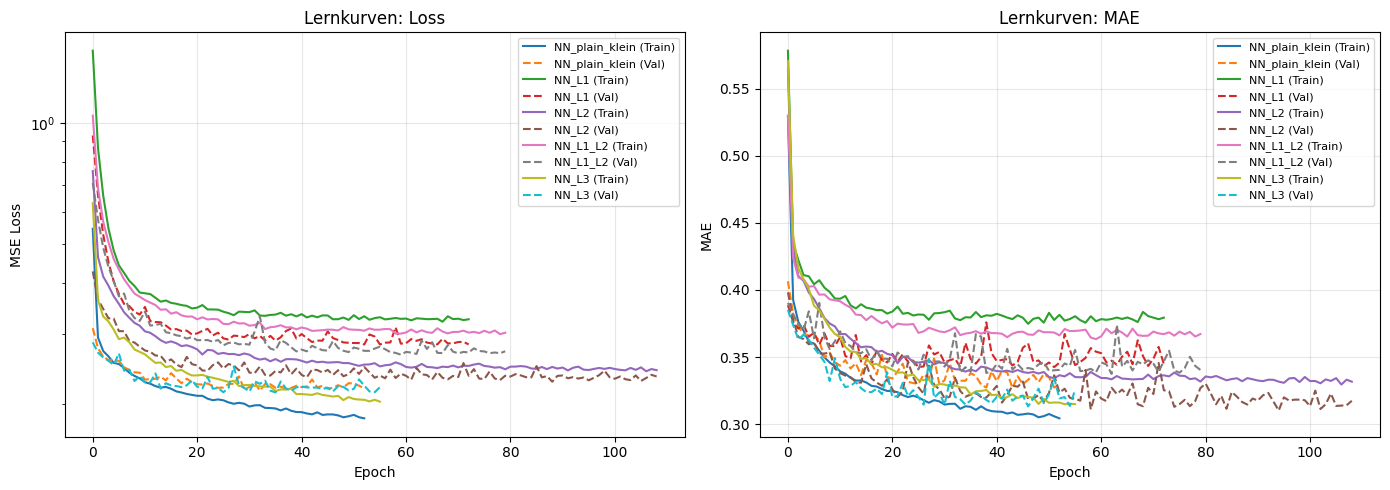

In [25]:
def plot_training_history(histories, names):
    """Lernkurven mehrerer Modelle."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for hist, name in zip(histories, names):
        axes[0].plot(hist.history['loss'], label=f'{name} (Train)')
        axes[0].plot(hist.history['val_loss'], '--', label=f'{name} (Val)')
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title('Lernkurven: Loss')
    axes[0].legend(fontsize=8)
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    for hist, name in zip(histories, names):
        axes[1].plot(hist.history['mae'], label=f'{name} (Train)')
        axes[1].plot(hist.history['val_mae'], '--', label=f'{name} (Val)')
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Lernkurven: MAE')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    fig.tight_layout()
    save_fig(fig, 'nn_learning_curves')
    return fig

fig = plot_training_history(
    list(histories.values()),
    list(histories.keys())
)

plt.show()

## 7.9 Vergleich NN vs. Lineare Regression

Gespeichert: results/nn_vs_linear_regression.png und results/nn_vs_linear_regression.pdf


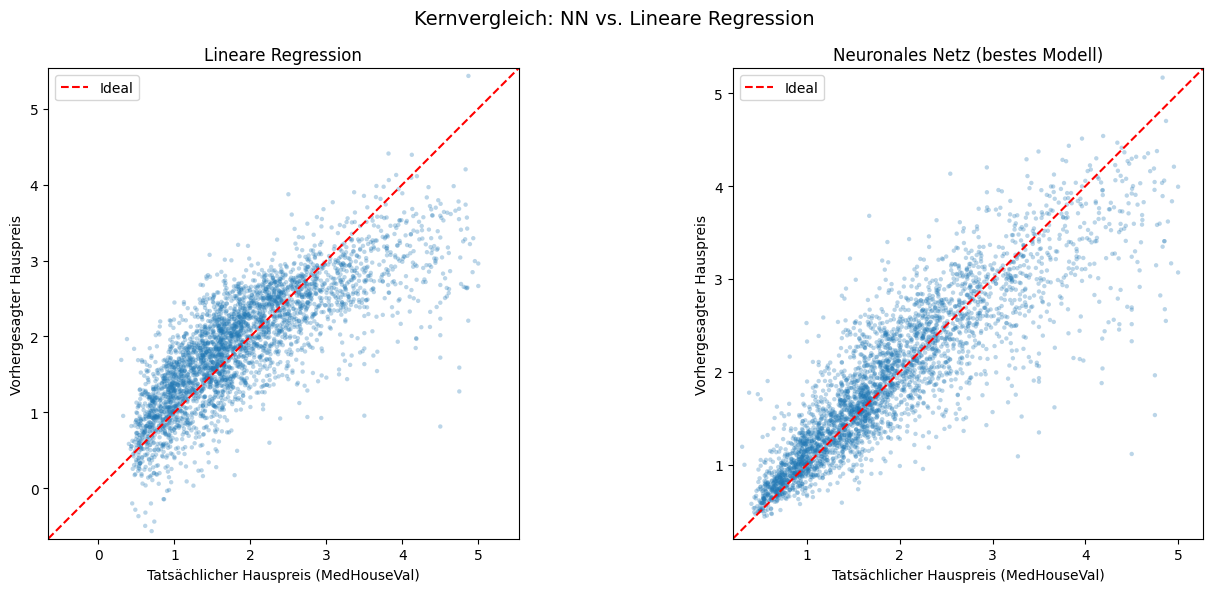

In [26]:
# Bestes NN-Modell vs. Lineare Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_predicted_vs_actual(
    y_test, lr.predict(X_test),
    title="Lineare Regression", ax=axes[0]
)

# Das beste NN-Modell (manuell auswählen nach Ergebnissen)
best_model_name = results_df.index[0]
best_nn = trained_models[best_model_name] # Anpassen je nach Ergebnis
y_pred_nn = best_nn.predict(X_test, verbose=0).flatten()
plot_predicted_vs_actual(
    y_test, y_pred_nn,
    title="Neuronales Netz (bestes Modell)", ax=axes[1]
)

fig.suptitle("Kernvergleich: NN vs. Lineare Regression", fontsize=14)
fig.tight_layout()
save_fig(fig, 'nn_vs_linear_regression')
plt.show()

## 7.10 Zusammenfassung

| Aspekt | Lineare Regression | Neuronales Netz |
|--------|-------------------|-----------------|
| R² Test | _eintragen_ | _eintragen_ |
| MAE Test | _eintragen_ | _eintragen_ |
| Trainingszeit | < 1s | _eintragen_ |
| Interpretierbarkeit | Hoch (Koeffizienten) | Gering (Black Box) |
| Hyperparameter | Keine | Architektur, LR, Epochs, ... |

**Fazit:**
- _Hier Ergebnisse und Interpretation eintragen_
- _Wann lohnt sich ein NN gegenüber linearer Regression?_
- _Grenzen und offene Fragen_